# **IV. Models**

### **IV.A. HD-SURDLM (Heterogeneous Dynamic Seemingly Unrelated Regression with Dynamic Linear Models) model**

#### **IV.A.1. Model**

Pros of this model: 

- takes into account multi-dimensional time-varying features
- cross-sectional stock analysis: correlations and spillover over assets, better than single-stock models

The extended model is articulated as: 

$$\begin{align}
&y_{j,t}=\alpha_J+(\sum^K_{k=1}X_{j,t,k}\beta_{j,t,k}) + Z_{j,t}\gamma_j / u_{j,t} \\
&\beta_{j,t,k}=\beta_{j,t-1,k}+v_{j,t,k}
\end{align}
$$

where 
- $j= 1,... , M$ denotes individual stocks
- $t = 1,... , T$ represents discrete time points
- $k= 1,... , K$ indexes over the time-varying features. 

It comprises:
- stock-specific intercepts $\alpha_j$
- time-varying features $X_{j, t, k}$ with coefficients $\beta_{j,t,k}$
- non-time-varying features $Z_{j,t}$ with coefficients $\gamma_j$. 

The model accounts for observation errors $u_{j,t} \sim \mathcal{N}_M(0, \Omega)$ and system errors $v_{j,t,k} \sim \mathcal{N}(0, \Omega)$, which are independent across time and features, with a covariance structure $\sum = A\Omega A$. 

The unknown parameters $\Theta = \{\alpha_j,\beta_{j,t,k},\gamma_j,\Omega\}_{j=1,...,M;t=1,...,T}$ collectively capture stock-specific effects, time-varying relationships, and error structures, enhancing the model’s adaptability to complex, dynamic stock return patterns across multiple assets. 

The model utilizes collected data $D=\{ y_{j,t},X_{j,t,k}, Z_{j,t}\}$, enabling a comprehensive analysis of multi-asset stock returns while accounting for both time-varying and static influences.


 
- $\alpha_j$ serves as the intercept for each stock $j$, epitomizing the intrisinc level of returns in the absence of influence by other variables. 

- The coefficients $\beta_{j,t,k}$ are pivotal, representing the time-varying impact of the $k$ th predictor $X_{j,t,k}$ on the returns of stock $j$ at time $t$ (they may evolve as per $\beta_{j,t,k}=\beta_{j,t-1,k}+v_{j,t,k}$), portraying the temporal variations in the relationships between predictors and returns.

- The model incorporate $\gamma_j$, the set of coefficients corresponding to the predictor vector Z_{j,t} for each stock $j$. Although these coefficient are static across time, their random nature allows fot th emodulation of the the predictors’ impact on returns.

- $\Omega$, encompassed within the unknown parameter vector $\Theta$, is not explicitly defined in the provided context but is potentially indicative of the variance–covariance matrix of the error terms, thereby capturing the variances and correlations in the model residuals.

- The model accommodates error terms representing the observation error and system error, respectively. $u_{j,t}$ accounts for the unexplained variability in stock returns. $v_{j,t,k}$ signifies the fluctuations in the time-varying regression coefficients, thereby contributing to the dynamic nature of the model. 

Collectively, the incorporation of these random parameters enhances the model’s adaptability and proficiency in capturing the multifaceted relationships between various predictors and stock returns across diverse stocks and temporal instances.

#### **IV.A.2. Stabilized Gibbs samplings**

*Gibbs sampling is a Markov chain Monte Carlo (MCMC) algorithm used for sampling from a multivariate probability distribution when direct sampling is difficult, by sampling from the conditional distributions of each variable.*

We introduce a novel, stable Gibbs sampling approach that not only enhances performance but also effectively handles multiple assets, uncovering potential inter-asset relationships.

*Sampling $\alpha$ and $\gamma$*. We sample the intercept vector $\alpha=(\alpha_1,...,\alpha_m)$ and the non-time-varying coefficient matric $\gamma=(\gamma_1,...,\gamma_M)$:

$(\alpha | D, \Theta \setminus \{\alpha\}) \sim \mathcal{N}(\mu_{\alpha}, \Sigma_{\alpha})$

$(\gamma | D, \Theta \setminus \{\gamma\}) \sim \mathcal{N}_{M \times p}(\mu_{\gamma}, \Sigma_{\gamma})$

where $D$ represents the data, $\Theta$ is the set of all parameters, and $p$ is the number of non-time-varying predictors. $\mu_{\alpha}$, $\Sigma_{\alpha}$, $\mu_{\gamma}$, and $\Sigma_{\gamma}$ are derived from the full conditional distributions.

Sampling $\beta$. We sample the time-varying coefficient tensors $\beta = (\beta_{1,t,k}, \dots, \beta_{M,t,k})$ for each time-varying feature $k = 1, \dots, K$:

$(\beta_{\cdot,\cdot,k} | D, \Theta \setminus \{\beta_{\cdot,\cdot,k}\}) \sim \mathcal{N}_{M \times T}(\mathbf{H}_k, \mathbf{B}_k)$

We use an improved Filter Forward Backward Sampling (FFBS) algorithm that processes all M stocks concurrently:
1. Forward filtration: Compute $\mathbf{m}_t$ and $\mathbf{C}_t$ sequentially for $t = 1, \dots, T$.
2. Backward sampling: For $t = T, \dots, 1$, sample
$\boldsymbol{\beta}_t \sim \mathcal{N}_M(\mathbf{h}_t, \mathbf{B}_t),$
where:

$\mathbf{h}_t = \mathbf{m}_t + \mathbf{C}_t \mathbf{R}_{t+1}^{-1} (\mathbf{m}_{t+1} - \mathbf{m}_t),$

$\mathbf{B}_t = \mathbf{C}_t + \mathbf{C}_t \mathbf{R}_{t+1}^{-1} \mathbf{B}_{t+1} \mathbf{R}_{t+1}^{-1} \mathbf{C}_t - \mathbf{C}_t \mathbf{R}_{t+1}^{-1} \mathbf{C}_t.$

This modification enhances numerical stability by using the computed mean $\mathbf{m}_{t+1}$ instead of the randomly sampled $\boldsymbol{\beta}_{t+1}$, reducing the accumulation of randomness in the backward sampling step.

Sampling $\boldsymbol{\Omega}$. We sample the joint variance–covariance matrix $\boldsymbol{\Omega}$, which captures cross-stock error correlations:
$(\boldsymbol{\Omega} | D \setminus \{\boldsymbol{\beta}\}, \Theta \setminus \{\boldsymbol{\Omega}\}) \sim \mathcal{IW}^{-1}(\nu, \boldsymbol{\Psi}),$

where:

$\nu = T - M + 2,$

$$\boldsymbol{\Psi} = \sum_{t=1}^{T} \mathbf{u}_t \mathbf{u}_t^\top. \tag{17}$$

We do not incorporate $\mathbf{v}_t$ (the difference between consecutive $\boldsymbol{\beta}_t$) in the sampling process. Instead, we recommend estimating $\boldsymbol{\Sigma}$ after the Gibbs sampling to ensure stability and prevent potential "viscous cycles" that could hinder convergence.

This novel approach allows for a more stable estimation of the overall model parameters, preventing situations where errors in estimating $\boldsymbol{\Omega}$ and $\boldsymbol{\beta}$ can reinforce each other, leading to poor convergence or instability in the Gibbs sampler.

Multi-step forecasting. We introduce a flexible approach to multi-step forecasting that accounts for increasing uncertainty across all M stocks simultaneously:

$\mathbf{Y}_{T+N} \sim \mathcal{N}_M(\boldsymbol{\mu}_{T+N}, \boldsymbol{\Sigma}_{T+N}),$

$\boldsymbol{\mu}_{T+N} = \boldsymbol{\alpha} + \mathbf{X}_{T+N} \mathbf{m}_T + \mathbf{Z}_{T+N} \boldsymbol{\gamma},$

$\boldsymbol{\Sigma}_{T+N} = \mathbf{F}_{T+N} (\mathbf{C}_N + T \boldsymbol{\Sigma}) \mathbf{F}_{T+N}^\top + \boldsymbol{\Omega}.$

Here, $\mathbf{Y}_{T+N}$ is an M-dimensional vector of stock returns, $\boldsymbol{\alpha}$ is the M-dimensional vector of intercepts, $\mathbf{X}_{T+N}$ and $\mathbf{Z}_{T+N}$ are matrices of time-varying and non-time-varying predictors for all M stocks, $\mathbf{m}_T$ is the matrix of final state estimates for the time-varying coefficients, and $\boldsymbol{\gamma}$ is the matrix of non-time-varying coefficients. $\mathbf{F}_{T+N}$ is a block-diagonal matrix of the time-varying predictors, $\mathbf{C}_N$ is the covariance matrix of the state estimates, and $\boldsymbol{\Omega}$ is the $M \times M$ cross-sectional covariance matrix of the errors.

This formulation allows for a more accurate representation of forecast uncertainty as the prediction horizon ($N$) increases while also capturing cross-sectional dependencies between stocks. The covariance matrix $\boldsymbol{\Sigma}_{T+N}$ grows with $N$, reflecting the increased uncertainty in longer-term forecasts, and its off-diagonal elements represent the co-movement of stock returns in future predictions.



##### **IV.A.3. Settings**


We set a simplified model running on half of the days in the sample, with 2000 iterations and 500 burn-in with target ret1. Missing headlines are filled using an EWMA (5-day window, 0.5 decay rate), missing tweet sentiments are filled based on most recent value. We iterate on all individual tweet sentiment combination (15), all headlines sentiment combinations (15) as well as all tweeter and headlines sentiment combination combos (15*15), all three averaging method. We experiment and iterature over various variables combinations: overnight and daily sentiment, different delta (noise-to-signal ratios), but also sentiment considered (using daily sentiment or sentiment over the past few days, or past few days + ewma with various decay factors) as input.

After 1,669 runs, we notice that the log-weighted average on tweet metrics performs better than the two other averaging methods. Models using oevrnight features represent 7 out of the ten best performing models. Best models often use VADER and BoW analysis. RoBERTa is never among the top performers. Both Tweets only, headlines only and mixed models perform good, but models using only tweets represent 8 out of the 10 best performing configurations for returns $d+1$.

Based on ret1 results, we iterate 720 models on the most promising features for ret7. Here, the best configuration often use solely headlines (6 out of the top 10), with no model based only on tweets.

### **IV.B. Benchmark models**

For benchmark models, the paper uses RandomForest, SVR, LASSO, MLP, RNN, LSTM and SURDLM. We also use a hybrid CNN-LSTM and DRL. We run them both as classifiers (up/down) and as continuous models as a benchmark for the HD-SURLM model.

In [37]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


0

In [24]:
import pandas as pd 

dfAAPL = pd.read_csv("data/training/AAPL_AVG3.csv", index_col=0, parse_dates=True)
dfAMZN = pd.read_csv("data/training/AMZN_AVG3.csv", index_col=0, parse_dates=True)
dfGOOG = pd.read_csv("data/training/GOOG_AVG3.csv", index_col=0, parse_dates=True)
dfGOOGL = pd.read_csv("data/training/GOOGL_AVG3.csv", index_col=0, parse_dates=True)
dfMSFT = pd.read_csv("data/training/MSFT_AVG3.csv", index_col=0, parse_dates=True)
dfTSLA = pd.read_csv("data/training/TSLA_AVG3.csv", index_col=0, parse_dates=True)

dfs = {"AAPL": dfAAPL, "AMZN": dfAMZN, "GOOG": dfGOOG, "GOOGL": dfGOOGL, "MSFT": dfMSFT, "TSLA": dfTSLA}

We first define two versions of X and Y features, with both continuous and binary features.

In [ ]:
import numpy as np

tickers = ["AAPL", "AMZN", "GOOG", "GOOGL", "MSFT", "TSLA"]

def ewma_weights(window_vals, alpha):
      weights = (1 - alpha) ** np.arange(len(window_vals))[::-1]
      return np.sum(weights * window_vals) / np.sum(weights)

for ticker in tickers: 
    # For missing tweets: ffil. For missing headlines: ewma 5d 0.5
    dfs[ticker][["TVADER", "TTBlob", "TBoW", "TRoBERTa"]] = dfs[ticker][["TVADER", "TTBlob", "TBoW", "TRoBERTa"]].ffill().fillna(0)
    dfs[ticker][["HLBoW", "HLTBlob", "HLVADER", "HLRoBERTa"]] = dfs[ticker][["HLBoW", "HLTBlob", "HLVADER","HLRoBERTa"]].apply(lambda col: col.fillna(col.rolling(window=5, min_periods=1).apply(lambda w: ewma_weights(w.values, 0.5) if len(w) == 5 else np.nan, raw=False))) 

    # Settings
    # AVG x
    #dfs[ticker][["TVADER", "TTBlob", "TBoW", "TRoBERTa"]] = dfs[ticker][["TVADER", "TTBlob", "TBoW", "TRoBERTa"]].rolling(window=8, min_periods=1).mean()
    #dfs[ticker][["HLBoW", "HLTBlob", "HLVADER", "HLRoBERTa"]] = dfs[ticker][["HLBoW", "HLTBlob", "HLVADER", "HLRoBERTa"]].rolling(window=8, min_periods=1).mean()

    # EWMA
    #dfs[ticker][["TVADER", "TTBlob", "TBoW", "TRoBERTa"]] = dfs[ticker][["TVADER", "TTBlob", "TBoW", "TRoBERTa"]].rolling(window=8, min_periods=1).apply(lambda w: ewma_weights(w.values, 0.1), raw=False)
    #dfs[ticker][["HLBoW", "HLTBlob", "HLVADER", "HLRoBERTa"]] = dfs[ticker][["HLBoW", "HLTBlob", "HLVADER", "HLRoBERTa"]].rolling(window=8, min_periods=1).apply(lambda w: ewma_weights(w.values, 0.1), raw=False)


    dfs[ticker]["T_SENT"] = dfs[ticker][["TVADER"]].mean(axis=1)
    #dfs[ticker]["HL_SENT"] = dfs[ticker][["HLBoW"]].mean(axis=1)   


# Creating binary variables
for ticker in tickers:
    for col in ["dlyret", "past_3ret", "past_7ret", "ret1", "ret7"]:
        dfs[ticker][f"{col}B"] = (dfs[ticker][col] > 0).astype(int)
    

# Continuous features and target
feature_cols = [
    "dlyret", "past_3ret", "past_7ret", "volumeSPX",
    "dlyretSPX", "VIX", "T_SENT",# "HL_SENT",
]

target_col = "ret1"

# Binary features and target

feature_colsB = [
    "dlyretB", "past_3retB", "past_7retB", "volumeSPX",
    "dlyretSPX", "VIX", "T_SENT", #"HL_SENT",
]

target_col = "ret1B"


#### **IV.B.1. Up**

Predicting always up.

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

for target in ['ret1', 'ret7']:
    print(f"\n{target}")
    
    precisions = []
    recalls = []
    f1s = []
    
    for ticker, df in dfs.items():
        y_true = (df[target] > 0).astype(int)
        y_pred = np.ones(len(y_true))
        
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        
        print(f"{ticker}: Pr/H-R: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    print(f"Mean: Pr/H-R: {np.mean(precisions):.4f}, Recall: {np.mean(recalls):.4f}, F1: {np.mean(f1s):.4f}")


ret1
AAPL: Pr/H-R: 0.5310, Recall: 1.0000, F1: 0.6937
AMZN: Pr/H-R: 0.4992, Recall: 1.0000, F1: 0.6660
GOOG: Pr/H-R: 0.5175, Recall: 1.0000, F1: 0.6820
GOOGL: Pr/H-R: 0.5143, Recall: 1.0000, F1: 0.6793
MSFT: Pr/H-R: 0.5294, Recall: 1.0000, F1: 0.6923
TSLA: Pr/H-R: 0.5079, Recall: 1.0000, F1: 0.6737
Mean: Pr/H-R: 0.5166, Recall: 1.0000, F1: 0.6812

ret7
AAPL: Pr/H-R: 0.5986, Recall: 1.0000, F1: 0.7489
AMZN: Pr/H-R: 0.5970, Recall: 1.0000, F1: 0.7476
GOOG: Pr/H-R: 0.5803, Recall: 1.0000, F1: 0.7344
GOOGL: Pr/H-R: 0.5835, Recall: 1.0000, F1: 0.7369
MSFT: Pr/H-R: 0.6025, Recall: 1.0000, F1: 0.7520
TSLA: Pr/H-R: 0.5326, Recall: 1.0000, F1: 0.6950
Mean: Pr/H-R: 0.5824, Recall: 1.0000, F1: 0.7358


#### **IV.B.2. Random Forest**

Running as both a classifier as a continuous regressor.

In [27]:
from sklearn.metrics import r2_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

def run_RnDFor(feature_cols, target_col, is_classification=False):

    results = []

    for ticker in tickers:
        df_ticker = dfs[ticker].copy()
        df_ticker = df_ticker.sort_index().iloc[:1258].copy()

        cols_needed = feature_cols + [target_col]
        df_ticker = df_ticker[cols_needed].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train = df_ticker.iloc[:split_idx]
        test = df_ticker.iloc[split_idx:]

        X_train = train[feature_cols]
        y_train = train[target_col]
        X_test = test[feature_cols]
        y_test = test[target_col]

        if is_classification:
            
            model = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_test))

            results.append({"ticker": ticker,"accuracy": accuracy,"precision": precision,"recall": recall,"f1": f1, "hit_rate": hit_rate})

        else:
            model = RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=5, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_pred_bin = (y_pred > 0).astype(int)
            y_test_bin = (y_test > 0).astype(int)


            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_test))
            r2 = r2_score(y_test, y_pred)
            precision = precision_score(y_test_bin, y_pred_bin)
            recall = recall_score(y_test_bin, y_pred_bin)
            f1 = f1_score(y_test_bin, y_pred_bin)

            results.append({"ticker": ticker, "hit_rate": hit_rate, "r2_oos": r2, "precision": precision, "recall": recall, "f1": f1})

    return pd.DataFrame(results)

results_reg = run_RnDFor(feature_cols, "ret1", is_classification=False)
results_clf = run_RnDFor(feature_colsB, "ret1B", is_classification=True)

print(results_reg)
print(f"Mean hit rate: {results_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_reg['r2_oos'].mean():.4f}")
print(f"Mean precision OOS: {results_reg['precision'].mean():.4f}")
print(f"Mean recall OOS: {results_reg['recall'].mean():.4f}")
print(f"Mean F1 OOS: {results_reg['f1'].mean():.4f}\n")

print(results_clf)
print(f"Mean hit rate: {results_clf['hit_rate'].mean():.4f}")
print(f"Mean accuracy: {results_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_clf['f1'].mean():.4f}")

  ticker  hit_rate    r2_oos  precision    recall        f1
0   AAPL  0.511905 -0.048962   0.577236  0.503546  0.537879
1   AMZN  0.452381 -0.100765   0.448598  0.377953  0.410256
2   GOOG  0.527778 -0.116105   0.560976  0.514925  0.536965
3  GOOGL  0.476190 -0.072197   0.491525  0.449612  0.469636
4   MSFT  0.503968 -0.064585   0.558140  0.514286  0.535316
5   TSLA  0.496032 -0.027261   0.540146  0.536232  0.538182
Mean hit rate: 0.4947
Mean R2 OOS: -0.0716
Mean precision OOS: 0.5294
Mean recall OOS: 0.4828
Mean F1 OOS: 0.5047

  ticker  accuracy  precision    recall        f1  hit_rate
0   AAPL  0.531746   0.577181  0.609929  0.593103  0.531746
1   AMZN  0.468254   0.469027  0.417323  0.441667  0.468254
2   GOOG  0.464286   0.495652  0.425373  0.457831  0.464286
3  GOOGL  0.492063   0.503937  0.496124  0.500000  0.492063
4   MSFT  0.484127   0.539683  0.485714  0.511278  0.484127
5   TSLA  0.476190   0.524194  0.471014  0.496183  0.476190
Mean hit rate: 0.4861
Mean accuracy: 0.4861
M

#### **IV.B.2. Lasso**

For this secondary benchmark, we first scale the features.

In [28]:
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def run_Lasso(feature_cols, target_col, is_classification=False):

    results = []

    for ticker in tickers:
        df_ticker = dfs[ticker].copy()
        df_ticker = df_ticker.sort_index().iloc[:1258].copy()

        cols_needed = feature_cols + [target_col]
        df_ticker = df_ticker[cols_needed].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train = df_ticker.iloc[:split_idx]
        test = df_ticker.iloc[split_idx:]

        X_train = train[feature_cols]
        y_train = train[target_col]
        X_test = test[feature_cols]
        y_test = test[target_col]

        if is_classification:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("logistic", LogisticRegressionCV(
                    Cs=np.logspace(-4, 0, 50),
                    cv=5,
                    max_iter=10000,
                    random_state=42,
                    n_jobs=-1,
                ))
            ])
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_test))
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            
            results.append({
                "ticker": ticker,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "C": model.named_steps["logistic"].C_[0],
                "hit_rate": hit_rate
            })
            
        else:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("lasso", LassoCV(
                    alphas=np.logspace(-4, 0, 50),
                    cv=5,
                    max_iter=10000,
                    random_state=42
                ))
            ])
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            y_pred_bin = (y_pred > 0).astype(int)
            y_test_bin = (y_test > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_test))
            r2 = r2_score(y_test, y_pred)
            precision = precision_score(y_test_bin, y_pred_bin, zero_division=0)
            recall = recall_score(y_test_bin, y_pred_bin)
            f1 = f1_score(y_test_bin, y_pred_bin)
            
            results.append({
                "ticker": ticker,
                "hit_rate": hit_rate,
                "r2_oos": r2,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "alpha": model.named_steps["lasso"].alpha_
            })
    
    return pd.DataFrame(results)

results_lasso_reg = run_Lasso(feature_cols, "ret1", is_classification=False)
results_lasso_clf = run_Lasso(feature_colsB, "ret1B", is_classification=True)

print(results_lasso_reg)
print(f"Mean hit rate: {results_lasso_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_lasso_reg['r2_oos'].mean():.4f}")
print(f"Mean precision: {results_lasso_reg['precision'].mean():.4f}")
print(f"Mean recall: {results_lasso_reg['recall'].mean():.4f}")
print(f"Mean F1: {results_lasso_reg['f1'].mean():.4f}\n")

print(results_lasso_clf)
print(f"Mean hit rate: {results_lasso_clf['hit_rate'].mean():.4f}")
print(f"Mean accuracy: {results_lasso_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_lasso_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_lasso_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_lasso_clf['f1'].mean():.4f}")

/Users/eyquem/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  ticker  hit_rate    r2_oos  precision    recall        f1     alpha
0   AAPL  0.559524 -0.026807   0.559524  1.000000  0.717557  1.000000
1   AMZN  0.496032 -0.001263   0.000000  0.000000  0.000000  1.000000
2   GOOG  0.543651 -0.016303   0.558282  0.679104  0.612795  0.000146
3  GOOGL  0.523810 -0.015679   0.532847  0.565891  0.548872  0.000121
4   MSFT  0.555556 -0.000028   0.555556  1.000000  0.714286  1.000000
5   TSLA  0.535714 -0.003361   0.554974  0.768116  0.644377  0.000954
Mean hit rate: 0.5357
Mean R2 OOS: -0.0106
Mean precision: 0.4602
Mean recall: 0.6689
Mean F1: 0.5396

  ticker  accuracy  precision    recall        f1         C  hit_rate
0   AAPL  0.559524   0.563025  0.950355  0.707124  0.009103  0.559524
1   AMZN  0.496032   0.000000  0.000000  0.000000  0.000100  0.496032
2   GOOG  0.531746   0.531746  1.000000  0.694301  0.000655  0.531746
3  GOOGL  0.515873   0.515695  0.891473  0.653409  0.003556  0.515873
4   MSFT  0.543651   0.551440  0.957143  0.699739  0.0013

#### **IV.B.4. SVR**

In [29]:
from sklearn.svm import SVR, SVC

def run_SVM(feature_cols, target_col, is_classification=False):

    results = []

    for ticker in tickers: 
        df_ticker = dfs[ticker].copy()
        df_ticker = df_ticker.sort_index().iloc[:1258].copy()

        cols_needed = feature_cols + [target_col]
        df_ticker = df_ticker[cols_needed].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train = df_ticker.iloc[:split_idx]
        test = df_ticker.iloc[split_idx:]

        X_train = train[feature_cols]
        y_train = train[target_col]
        X_test = test[feature_cols]
        y_test = test[target_col]

        if is_classification:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("svc", SVC(kernel="rbf", C=1.0, random_state=42, class_weight='balanced'))
            ])
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_test))
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "hit_rate": hit_rate
            })
            
        else:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1))
            ])
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            y_pred_bin = (y_pred > 0).astype(int)
            y_test_bin = (y_test > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_test))
            r2 = r2_score(y_test, y_pred)
            precision = precision_score(y_test_bin, y_pred_bin, zero_division=0)
            recall = recall_score(y_test_bin, y_pred_bin, zero_division=0)
            f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "hit_rate": hit_rate,
                "r2_oos": r2,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
    
    return pd.DataFrame(results)

results_svm_reg = run_SVM(feature_cols, "ret1", is_classification=False)
results_svm_clf = run_SVM(feature_colsB, "ret1B", is_classification=True)

print(results_svm_reg)
print(f"Mean hit rate: {results_svm_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_svm_reg['r2_oos'].mean():.4f}")
print(f"Mean precision: {results_svm_reg['precision'].mean():.4f}")
print(f"Mean recall: {results_svm_reg['recall'].mean():.4f}")
print(f"Mean F1: {results_svm_reg['f1'].mean():.4f}\n")

print(results_svm_clf)
print(f"Mean hit rate: {results_svm_clf['hit_rate'].mean():.4f}")
print(f"Mean accuracy: {results_svm_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_svm_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_svm_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_svm_clf['f1'].mean():.4f}")

  ticker  hit_rate    r2_oos  precision  recall        f1
0   AAPL  0.559524 -0.678423   0.559524     1.0  0.717557
1   AMZN  0.496032 -0.280054   0.000000     0.0  0.000000
2   GOOG  0.468254 -0.157678   0.000000     0.0  0.000000
3  GOOGL  0.484127 -0.164742   0.000000     0.0  0.000000
4   MSFT  0.444444 -0.006679   0.000000     0.0  0.000000
5   TSLA  0.547619 -0.989222   0.547619     1.0  0.707692
Mean hit rate: 0.5000
Mean R2 OOS: -0.3795
Mean precision: 0.1845
Mean recall: 0.3333
Mean F1: 0.2375

  ticker  accuracy  precision    recall        f1  hit_rate
0   AAPL  0.511905   0.555556  0.638298  0.594059  0.511905
1   AMZN  0.492063   0.495798  0.464567  0.479675  0.492063
2   GOOG  0.480159   0.508876  0.641791  0.567657  0.480159
3  GOOGL  0.488095   0.500000  0.651163  0.565657  0.488095
4   MSFT  0.484127   0.552083  0.378571  0.449153  0.484127
5   TSLA  0.480159   0.528926  0.463768  0.494208  0.480159
Mean hit rate: 0.4894
Mean accuracy: 0.4894
Mean precision: 0.5235
Mean

#### **IV.B.5. MLP**

In [30]:
from sklearn.neural_network import MLPRegressor, MLPClassifier

def run_MLP(feature_cols, target_col, is_classification=False):

    results = []

    for ticker in tickers:
        df_ticker = dfs[ticker].copy()
        df_ticker = df_ticker.sort_index().iloc[:1258].copy()

        cols_needed = feature_cols + [target_col]
        df_ticker = df_ticker[cols_needed].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train = df_ticker.iloc[:split_idx]
        test = df_ticker.iloc[split_idx:]

        X_train = train[feature_cols]
        y_train = train[target_col]
        X_test = test[feature_cols]
        y_test = test[target_col]

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        if is_classification:
            model = MLPClassifier(
                hidden_layer_sizes=(50, 50),
                activation='relu',
                solver='adam',
                alpha=0.001,
                batch_size='auto',
                learning_rate='constant',
                learning_rate_init=0.001,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=10,
                random_state=42
            )
            
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_test))
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "hit_rate": hit_rate
            })
            
        else:
            model = MLPRegressor(
                hidden_layer_sizes=(50, 50),
                activation='relu',
                solver='adam',
                alpha=0.001,
                batch_size='auto',
                learning_rate='constant',
                learning_rate_init=0.001,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=10,
                random_state=42
            )
            
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            
            y_pred_bin = (y_pred > 0).astype(int)
            y_test_bin = (y_test > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_test))
            r2 = r2_score(y_test, y_pred)
            precision = precision_score(y_test_bin, y_pred_bin, zero_division=0)
            recall = recall_score(y_test_bin, y_pred_bin, zero_division=0)
            f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "hit_rate": hit_rate,
                "r2_oos": r2,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
    
    return pd.DataFrame(results)

results_mlp_reg = run_MLP(feature_cols, "ret1", is_classification=False)
results_mlp_clf = run_MLP(feature_colsB, "ret1B", is_classification=True)

print(results_mlp_reg)
print(f"Mean hit rate: {results_mlp_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_mlp_reg['r2_oos'].mean():.4f}")
print(f"Mean precision: {results_mlp_reg['precision'].mean():.4f}")
print(f"Mean recall: {results_mlp_reg['recall'].mean():.4f}")
print(f"Mean F1: {results_mlp_reg['f1'].mean():.4f}\n")

print(results_mlp_clf)
print(f"Mean hit rate: {results_mlp_clf['hit_rate'].mean():.4f}")
print(f"Mean accuracy: {results_mlp_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_mlp_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_mlp_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_mlp_clf['f1'].mean():.4f}")

  ticker  hit_rate    r2_oos  precision    recall        f1
0   AAPL  0.496032 -5.657539   0.558333  0.475177  0.513410
1   AMZN  0.448413 -7.216810   0.456522  0.496063  0.475472
2   GOOG  0.476190 -6.341547   0.508333  0.455224  0.480315
3  GOOGL  0.488095 -5.850093   0.503401  0.573643  0.536232
4   MSFT  0.500000 -9.782218   0.560345  0.464286  0.507812
5   TSLA  0.503968 -1.748311   0.559322  0.478261  0.515625
Mean hit rate: 0.4854
Mean R2 OOS: -6.0994
Mean precision: 0.5244
Mean recall: 0.4904
Mean F1: 0.5048

  ticker  accuracy  precision    recall        f1  hit_rate
0   AAPL  0.511905   0.548387  0.723404  0.623853  0.511905
1   AMZN  0.503968   0.508929  0.448819  0.476987  0.503968
2   GOOG  0.539683   0.552941  0.701493  0.618421  0.539683
3  GOOGL  0.456349   0.475904  0.612403  0.535593  0.456349
4   MSFT  0.500000   0.547945  0.571429  0.559441  0.500000
5   TSLA  0.468254   0.516949  0.442029  0.476562  0.468254
Mean hit rate: 0.4967
Mean accuracy: 0.4967
Mean precisio

#### **IV.B.6. RNN**

With 8 features and 1 target, we use the multivariate time series model given in the class. Requires Python ≤ 3.10.x.

In [31]:
import tensorflow as tf


def run_RNN(feature_cols, target_col, is_classification=False):

    results = []

    SEQ_LENGTH = 40
    BATCH_SIZE = 32
    EPOCHS = 500
    PATIENCE = 50

    for ticker in tickers:

        df_ticker = dfs[ticker].copy().sort_index().iloc[:1258]
        cols = feature_cols + [target_col]
        df_ticker = df_ticker[cols].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train_df = df_ticker.iloc[:split_idx]
        test_df = df_ticker.iloc[split_idx:]

        # Scaling
        scaler_X = StandardScaler()
        scaler_y = StandardScaler() 

        X_train = scaler_X.fit_transform(train_df[feature_cols].values)
        y_train = scaler_y.fit_transform(train_df[[target_col]].values).flatten()
        X_test = scaler_X.transform(test_df[feature_cols].values)
        y_test = scaler_y.transform(test_df[[target_col]].values).flatten()

        train_ds = tf.keras.utils.timeseries_dataset_from_array(
            X_train,
            targets=y_train[SEQ_LENGTH:],
            sequence_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=42
        )
        test_ds = tf.keras.utils.timeseries_dataset_from_array(
            X_test,
            targets=y_test[SEQ_LENGTH:],
            sequence_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        if is_classification:
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
                tf.keras.layers.SimpleRNN(32),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=PATIENCE, restore_best_weights=True
            )
            
            model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, 
                      callbacks=[early_stop], verbose=0)
            
            y_pred_proba = model.predict(test_ds).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)
            y_true = (y_test[SEQ_LENGTH:] > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_true))
            accuracy = accuracy_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "hit_rate": hit_rate
            })
            
        else:
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
                tf.keras.layers.SimpleRNN(32),
                tf.keras.layers.Dense(1)
            ])
            
            model.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
            
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_mae', patience=PATIENCE, restore_best_weights=True
            )
            
            model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, 
                      callbacks=[early_stop], verbose=0)
            
            y_pred_scaled = model.predict(test_ds).flatten()
            y_true_scaled = y_test[SEQ_LENGTH:]
            
            y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
            y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
            
            y_pred_bin = (y_pred > 0).astype(int)
            y_true_bin = (y_true > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_true))
            r2 = r2_score(y_true, y_pred)
            precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
            recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
            f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "hit_rate": hit_rate,
                "r2_oos": r2,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
    
    return pd.DataFrame(results)

results_rnn_reg = run_RNN(feature_cols, "ret1", is_classification=False)
results_rnn_clf = run_RNN(feature_colsB, "ret1B", is_classification=True)

# Affichage
print(results_rnn_reg)
print(f"Mean hit rate: {results_rnn_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_rnn_reg['r2_oos'].mean():.4f}")
print(f"Mean precision: {results_rnn_reg['precision'].mean():.4f}")
print(f"Mean recall: {results_rnn_reg['recall'].mean():.4f}")
print(f"Mean F1: {results_rnn_reg['f1'].mean():.4f}\n")

print(results_rnn_clf)
print(f"Mean hit rate: {results_rnn_clf['hit_rate'].mean():.4f}")
print(f"Mean accuracy: {results_rnn_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_rnn_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_rnn_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_rnn_clf['f1'].mean():.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
  ticker  hit_rate    r2_oos  precision    recall        f1
0   AAPL  0.537736 -0.062914   0.594595  0.559322  0.576419
1   AMZN  0.523585 -0.120100   0.520408  0.485714  0.502463
2   GOOG  0.481132 -0.130141   0.519231  0.473684  0.495413
3  GOOGL  0.561321 -0.071852   0.577982  0.572727  0.575342
4   MSFT  0.533019 -0.076400   0.570248  0.594828  0.582278
5   TSLA  0.509434 -0.083836   0.541667  0.570175  0.555556
Mean hit rate: 0.5244
Mean R2 OOS: -0.0909
Mean precision: 0.5540
Mean recall: 0.5427
Mean F1: 0.5479

  ticker  accuracy  p

#### **IV.B.7. LSTM**

In [32]:
def run_LSTM(feature_cols, target_col, is_classification=False):
    
    results = []

    # Config
    SEQ_LENGTH = 40 
    BATCH_SIZE = 32
    EPOCHS = 500
    PATIENCE = 50

    for ticker in tickers:

        df_ticker = dfs[ticker].copy().sort_index().iloc[:1258]
        cols = feature_cols + [target_col]
        df_ticker = df_ticker[cols].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train_df = df_ticker.iloc[:split_idx]
        test_df = df_ticker.iloc[split_idx:]

        # Scaling
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        X_train = scaler_X.fit_transform(train_df[feature_cols].values)
        y_train = scaler_y.fit_transform(train_df[[target_col]].values).flatten()
        X_test = scaler_X.transform(test_df[feature_cols].values)
        y_test = scaler_y.transform(test_df[[target_col]].values).flatten()

        train_ds = tf.keras.utils.timeseries_dataset_from_array(
            X_train,
            targets=y_train[SEQ_LENGTH:],
            sequence_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=42
        )
        test_ds = tf.keras.utils.timeseries_dataset_from_array(
            X_test,
            targets=y_test[SEQ_LENGTH:],
            sequence_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        if is_classification:
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
                tf.keras.layers.LSTM(32),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=PATIENCE, restore_best_weights=True
            )
            
            model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, 
                      callbacks=[early_stop], verbose=0)
            
            y_pred_proba = model.predict(test_ds).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)
            y_true = (y_test[SEQ_LENGTH:] > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_true))
            accuracy = accuracy_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "hit_rate": hit_rate
            })
            
        else:
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
                tf.keras.layers.LSTM(32),
                tf.keras.layers.Dense(1)
            ])
            
            model.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
            
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_mae', patience=PATIENCE, restore_best_weights=True
            )
            
            model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, 
                      callbacks=[early_stop], verbose=0)
            
            y_pred_scaled = model.predict(test_ds).flatten()
            y_true_scaled = y_test[SEQ_LENGTH:]
            
            y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
            y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
            
            y_pred_bin = (y_pred > 0).astype(int)
            y_true_bin = (y_true > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_true))
            r2 = r2_score(y_true, y_pred)
            precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
            recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
            f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "hit_rate": hit_rate,
                "r2_oos": r2,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
    
    return pd.DataFrame(results)

results_lstm_reg = run_LSTM(feature_cols, "ret1", is_classification=False)
results_lstm_clf = run_LSTM(feature_colsB, "ret1B", is_classification=True)


print(results_lstm_reg)
print(f"Mean hit rate: {results_lstm_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_lstm_reg['r2_oos'].mean():.4f}")
print(f"Mean precision: {results_lstm_reg['precision'].mean():.4f}")
print(f"Mean recall: {results_lstm_reg['recall'].mean():.4f}")
print(f"Mean F1: {results_lstm_reg['f1'].mean():.4f}\n")

print(results_lstm_clf)
print(f"Mean hit rate: {results_lstm_clf['hit_rate'].mean():.4f}")
print(f"Mean accuracy: {results_lstm_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_lstm_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_lstm_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_lstm_clf['f1'].mean():.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
  ticker  hit_rate    r2_oos  precision    recall        f1
0   AAPL  0.551887 -0.007495   0.562842  0.872881  0.684385
1   AMZN  0.466981 -0.002934   0.461538  0.457143  0.459330
2   GOOG  0.500000 -0.031242   0.533333  0.561404  0.547009
3  GOOGL  0.528302 -0.019403   0.536765  0.663636  0.593496
4   MSFT  0.518868  0.004169   0.561404  0.551724  0.556522
5   TSLA  0.495283 -0.035034   0.530435  0.535088  0.532751
Mean hit rate: 0.5102
Mean R2 OOS: -0.0153
Mean precision: 0.5311
Mean recall: 0.6070
Mean F1: 0.5622

  ticker  accuracy  p

#### **IV.B.8. CNN-LSTM**


In [33]:
def run_CNN_LSTM(feature_cols, target_col, is_classification=False):

    results = []

    # Config
    SEQ_LENGTH = 40 
    BATCH_SIZE = 32
    EPOCHS = 500
    PATIENCE = 50

    for ticker in tickers:

        df_ticker = dfs[ticker].copy().sort_index().iloc[:1258]
        cols = feature_cols + [target_col]
        df_ticker = df_ticker[cols].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train_df = df_ticker.iloc[:split_idx]
        test_df = df_ticker.iloc[split_idx:]

        # Scaling
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        X_train = scaler_X.fit_transform(train_df[feature_cols].values)
        y_train = scaler_y.fit_transform(train_df[[target_col]].values).flatten()
        X_test = scaler_X.transform(test_df[feature_cols].values)
        y_test = scaler_y.transform(test_df[[target_col]].values).flatten()

        train_ds = tf.keras.utils.timeseries_dataset_from_array(
            X_train,
            targets=y_train[SEQ_LENGTH:],
            sequence_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=42
        )
        test_ds = tf.keras.utils.timeseries_dataset_from_array(
            X_test,
            targets=y_test[SEQ_LENGTH:],
            sequence_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        if is_classification:
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
                tf.keras.layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'),
                tf.keras.layers.MaxPooling1D(pool_size=2),
                tf.keras.layers.LSTM(32),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=PATIENCE, restore_best_weights=True
            )
            
            model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, 
                      callbacks=[early_stop], verbose=0)
            
            y_pred_proba = model.predict(test_ds).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)
            y_true = (y_test[SEQ_LENGTH:] > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_true))
            accuracy = accuracy_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "hit_rate": hit_rate
            })
            
        else:
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
                tf.keras.layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'),
                tf.keras.layers.MaxPooling1D(pool_size=2),
                tf.keras.layers.LSTM(32),
                tf.keras.layers.Dense(1)
            ])
            
            model.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
            
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_mae', patience=PATIENCE, restore_best_weights=True
            )
            
            model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, 
                      callbacks=[early_stop], verbose=0)
            
            y_pred_scaled = model.predict(test_ds).flatten()
            y_true_scaled = y_test[SEQ_LENGTH:]
            
            y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
            y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
            
            y_pred_bin = (y_pred > 0).astype(int)
            y_true_bin = (y_true > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_true))
            r2 = r2_score(y_true, y_pred)
            precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
            recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
            f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "hit_rate": hit_rate,
                "r2_oos": r2,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
    
    return pd.DataFrame(results)


results_cnn_lstm_reg = run_CNN_LSTM(feature_cols, "ret1", is_classification=False)
results_cnn_lstm_clf = run_CNN_LSTM(feature_colsB, "ret1B", is_classification=True)


print(results_cnn_lstm_reg)
print(f"Mean hit rate: {results_cnn_lstm_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_cnn_lstm_reg['r2_oos'].mean():.4f}")
print(f"Mean precision: {results_cnn_lstm_reg['precision'].mean():.4f}")
print(f"Mean recall: {results_cnn_lstm_reg['recall'].mean():.4f}")
print(f"Mean F1: {results_cnn_lstm_reg['f1'].mean():.4f}\n")

print(results_cnn_lstm_clf)
print(f"Mean hit rate: {results_cnn_lstm_clf['hit_rate'].mean():.4f}")
print(f"Mean accuracy: {results_cnn_lstm_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_cnn_lstm_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_cnn_lstm_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_cnn_lstm_clf['f1'].mean():.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
  ticker  hit_rate    r2_oos  precision    recall        f1
0   AAPL  0.575472 -0.012207   0.573684  0.923729  0.707792
1   AMZN  0.476415 -0.023384   0.428571  0.171429  0.244898
2   GOOG  0.533019 -0.002988   0.561983  0.596491  0.578723
3  GOOGL  0.457547 -0.022230   0.474359  0.336364  0.393617
4   MSFT  0.561321  0.017429   0.568862  0.818966  0.671378
5   TSLA  0.514151 -0.040451   0.530726  0.833333  0.648464
Mean hit rate: 0.5197
Mean R2 OOS: -0.0140
Mean precision: 0.5230
Mean recall: 0.6134
Mean F1: 0.5408

  ticker  accuracy  p

### **IV.C. Backtest**

Trades: 227
Final capital: 15144.87
Total return: 51.45 %
Win rate: 56.39 %
Max drawdown: -8.44 %
Sharpe ratio: 2.5534
Profit factor: 1.5673


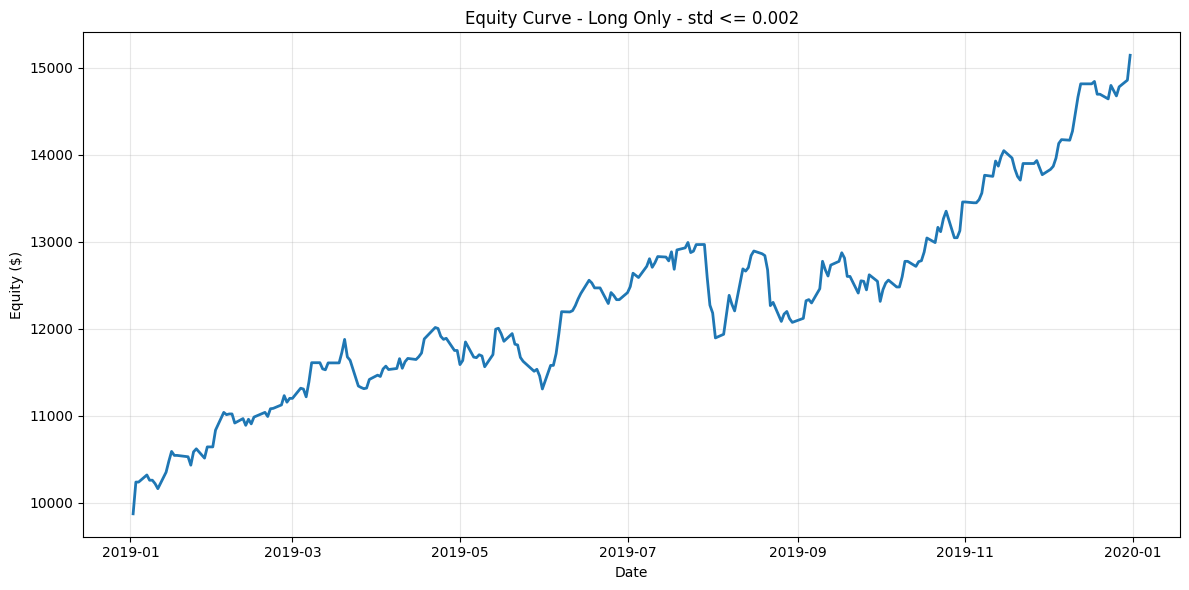

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE = "data/predictions_ret1_TVADER_NOAVG_delta0.9.csv"
THRESHOLD = 0.002
INITIAL_CAPITAL = 10_000.0
RISK_FREE_RATE_DAILY = 0.03 / 252

df = pd.read_csv(FILE)

pred_tickers = [c[:-5] for c in df.columns if c.endswith("_pred")]
pred_tickers = sorted(pred_tickers)

capital = INITIAL_CAPITAL
equity_curve = []
trades = []

for _, row in df.iterrows():
    trade_taken = False

    for ticker in pred_tickers:
        pred = row[f"{ticker}_pred"]
        std = row[f"{ticker}_std"]
        actual = row[f"{ticker}_actual"]

        if std <= THRESHOLD and pred > 0:
            entry_capital = capital
            exit_capital = entry_capital * (1.0 + actual)
            pnl = exit_capital - entry_capital
            trade_return = actual

            capital = exit_capital
            trades.append({
                "date": row["date"],
                "ticker": ticker,
                "pred": pred,
                "std": std,
                "actual": actual,
                "entry_capital": entry_capital,
                "exit_capital": exit_capital,
                "pnl": pnl,
                "trade_return": trade_return,
            })

            trade_taken = True
            break

    equity_curve.append({
        "date": row["date"],
        "equity": capital,
        "daily_return": (capital / equity_curve[-1]["equity"] - 1.0) if equity_curve else 0.0,
        "trade_taken": trade_taken,
    })

trades_df = pd.DataFrame(trades)
equity_df = pd.DataFrame(equity_curve)
equity_df["date"] = pd.to_datetime(equity_df["date"])
equity_df = equity_df.sort_values("date").reset_index(drop=True)

# Recompute daily returns properly from the equity curve
equity_df["daily_return"] = equity_df["equity"].pct_change().fillna(0.0)

# Max drawdown
equity_df["running_max"] = equity_df["equity"].cummax()
equity_df["drawdown"] = equity_df["equity"] / equity_df["running_max"] - 1.0
max_drawdown = equity_df["drawdown"].min()

# Sharpe ratio annualized from daily returns
excess_returns = equity_df["daily_return"] - RISK_FREE_RATE_DAILY
ret_std = excess_returns.std(ddof=1)
sharpe = np.nan if ret_std == 0 or np.isnan(ret_std) else np.sqrt(252) * excess_returns.mean() / ret_std

# Profit factor
gross_profit = trades_df.loc[trades_df["pnl"] > 0, "pnl"].sum()
gross_loss = -trades_df.loc[trades_df["pnl"] < 0, "pnl"].sum()
profit_factor = np.inf if gross_loss == 0 else gross_profit / gross_loss

# Summary
final_capital = capital
total_return = final_capital / INITIAL_CAPITAL - 1.0
n_trades = len(trades_df)
win_rate = (trades_df["pnl"] > 0).mean() if n_trades else np.nan

print("Trades:", n_trades)
print("Final capital:", round(final_capital, 2))
print("Total return:", round(total_return * 100, 2), "%")
print("Win rate:", round(win_rate * 100, 2), "%")
print("Max drawdown:", round(max_drawdown * 100, 2), "%")
print("Sharpe ratio:", round(sharpe, 4) if pd.notna(sharpe) else sharpe)
print("Profit factor:", round(profit_factor, 4) if np.isfinite(profit_factor) else profit_factor)

# Save trades if needed
# trades_df.to_csv("/Users/eyquem/Desktop/results/backtest_trades_tvader_noavg_0002.csv", index=False)

# Plot equity curve
plt.figure(figsize=(12, 6))
plt.plot(equity_df["date"], equity_df["equity"], linewidth=2)
plt.title(f"Equity Curve - Long Only - std <= {THRESHOLD}")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Trades: 52
Final capital: 18055.4
Total return: 80.55 %
Win rate: 61.54 %
Max drawdown: -17.42 %
Sharpe ratio: 2.0637
Profit factor: 2.4482


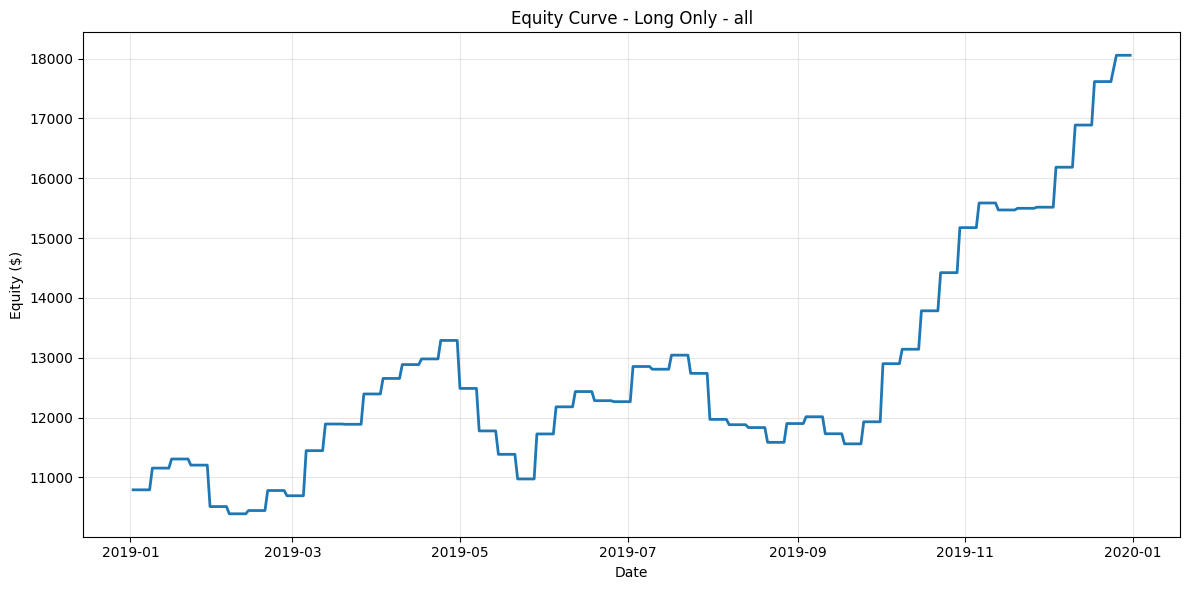

In [4]:
FILE = "data/predictions_ret7_HLBoW_AVG8_delta0.98.csv"
INITIAL_CAPITAL = 10_000.0
RISK_FREE_RATE_DAILY = 0.03 / 252
HOLDING_PERIOD = 7  # jours de pause après un trade

df = pd.read_csv(FILE)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

pred_tickers = [c[:-5] for c in df.columns if c.endswith("_pred")]
pred_tickers = sorted(pred_tickers)

capital = INITIAL_CAPITAL
equity_curve = []
trades = []
next_available_date = None  # date à partir de laquelle on peut retrader

for _, row in df.iterrows():
    trade_taken = False

    # On ne trade que si la position précédente est "fermée"
    if next_available_date is None or row["date"] >= next_available_date:
        for ticker in pred_tickers:
            pred = row[f"{ticker}_pred"]
            std = row[f"{ticker}_std"]
            actual = row[f"{ticker}_actual"]
            if pred > 0:
                entry_capital = capital
                exit_capital = entry_capital * (1.0 + actual)
                pnl = exit_capital - entry_capital
                capital = exit_capital
                trades.append({
                    "date": row["date"],
                    "ticker": ticker,
                    "pred": pred,
                    "std": std,
                    "actual": actual,
                    "entry_capital": entry_capital,
                    "exit_capital": exit_capital,
                    "pnl": pnl,
                    "trade_return": actual,
                })
                trade_taken = True
                next_available_date = row["date"] + pd.Timedelta(days=HOLDING_PERIOD)
                break

    equity_curve.append({
        "date": row["date"],
        "equity": capital,
        "trade_taken": trade_taken,
    })

trades_df = pd.DataFrame(trades)
equity_df = pd.DataFrame(equity_curve)
equity_df["daily_return"] = equity_df["equity"].pct_change().fillna(0.0)
equity_df["running_max"] = equity_df["equity"].cummax()
equity_df["drawdown"] = equity_df["equity"] / equity_df["running_max"] - 1.0
max_drawdown = equity_df["drawdown"].min()

excess_returns = equity_df["daily_return"] - RISK_FREE_RATE_DAILY
ret_std = excess_returns.std(ddof=1)
sharpe = np.nan if ret_std == 0 or np.isnan(ret_std) else np.sqrt(252) * excess_returns.mean() / ret_std

gross_profit = trades_df.loc[trades_df["pnl"] > 0, "pnl"].sum()
gross_loss = -trades_df.loc[trades_df["pnl"] < 0, "pnl"].sum()
profit_factor = np.inf if gross_loss == 0 else gross_profit / gross_loss

final_capital = capital
total_return = final_capital / INITIAL_CAPITAL - 1.0
n_trades = len(trades_df)
win_rate = (trades_df["pnl"] > 0).mean() if n_trades else np.nan

print("Trades:", n_trades)
print("Final capital:", round(final_capital, 2))
print("Total return:", round(total_return * 100, 2), "%")
print("Win rate:", round(win_rate * 100, 2), "%")
print("Max drawdown:", round(max_drawdown * 100, 2), "%")
print("Sharpe ratio:", round(sharpe, 4) if pd.notna(sharpe) else sharpe)
print("Profit factor:", round(profit_factor, 4) if np.isfinite(profit_factor) else profit_factor)

plt.figure(figsize=(12, 6))
plt.plot(equity_df["date"], equity_df["equity"], linewidth=2)
plt.title(f"Equity Curve - Long Only - all")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
FILE = "data/predictions_ret1_TVADER_NOAVG_delta0.9.csv"
INITIAL_CAPITAL = 10_000.0

df = pd.read_csv(FILE)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

actual_tickers = [c[:-7] for c in df.columns if c.endswith("_actual")]
actual_tickers = sorted(actual_tickers)
n_tickers = len(actual_tickers)

# Capital initial réparti équitablement entre tickers
capital_per_ticker = {t: INITIAL_CAPITAL / n_tickers for t in actual_tickers}

equity_curve = []
for _, row in df.iterrows():
    for t in actual_tickers:
        ret = row[f"{t}_actual"]
        if pd.notna(ret):
            capital_per_ticker[t] *= (1.0 + ret)
    total_equity = sum(capital_per_ticker.values())
    equity_curve.append({"date": row["date"], "equity": total_equity})

equity_df = pd.DataFrame(equity_curve)
equity_df["daily_return"] = equity_df["equity"].pct_change().fillna(0.0)
equity_df["running_max"] = equity_df["equity"].cummax()
equity_df["drawdown"] = equity_df["equity"] / equity_df["running_max"] - 1.0

final_capital = equity_df["equity"].iloc[-1]
total_return = final_capital / INITIAL_CAPITAL - 1.0
max_drawdown = equity_df["drawdown"].min()

RISK_FREE_RATE_DAILY = 0.03 / 252
excess_returns = equity_df["daily_return"] - RISK_FREE_RATE_DAILY
ret_std = excess_returns.std(ddof=1)
sharpe = np.nan if ret_std == 0 or np.isnan(ret_std) else np.sqrt(252) * excess_returns.mean() / ret_std

print("Buy & Hold (equally weighted)")
print("Final capital:", round(final_capital, 2))
print("Total return:", round(total_return * 100, 2), "%")
print("Max drawdown:", round(max_drawdown * 100, 2), "%")
print("Sharpe ratio:", round(sharpe, 4) if pd.notna(sharpe) else sharpe)

Buy & Hold (equally weighted)
Final capital: 12868.96
Total return: 28.69 %
Max drawdown: -6.14 %
Sharpe ratio: 1.7244
